In [1]:
#  python=3.10
# !pip install speechbrain=0.5.15
# !pip

In [2]:
import os
import collections
import numpy as np
from numpy.lib.format import open_memmap
from pathlib import Path
from tqdm import tqdm
import openwakeword
import openwakeword.data
import openwakeword.utils
import openwakeword.metrics

import scipy
import datasets
import matplotlib.pyplot as plt
import torch
from torch import nn
import IPython.display as ipd

/Users/jingyehuang/miniconda3/envs/python310/lib/python3.10/site-packages/pronouncing/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream
/Users/jingyehuang/miniconda3/envs/python310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
torchvision is not available - cannot save figures


In [3]:
# Load the data prepared in previous steps (it's small enough to load entirely in memory)

negative_features = np.load("negative_features.npy")
positive_features = np.load("positive_features.npy")

X = np.vstack((negative_features, positive_features))
y = np.array([0]*len(negative_features) + [1]*len(positive_features)).astype(np.float32)[...,None]

# Make Pytorch dataloader
batch_size = 512
training_data = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
    batch_size = batch_size,
    shuffle = True
)

定义模型

In [4]:
# Define fully-connected network in PyTorch

layer_dim = 32
fcn = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(X.shape[1]*X.shape[2], layer_dim), # since the input is flattened, it's timesteps*feature columns
                    nn.LayerNorm(layer_dim),
                    nn.ReLU(),
                    nn.Linear(layer_dim, layer_dim),
                    nn.LayerNorm(layer_dim),
                    nn.ReLU(),
                    nn.Linear(layer_dim, 1),
                    nn.Sigmoid(),
                )

loss_function = torch.nn.functional.binary_cross_entropy
optimizer = torch.optim.Adam(fcn.parameters(), lr=0.001)

### 训练模型

In [5]:
# Define training loop, metrics, and logging

n_epochs = 10
history = collections.defaultdict(list)
for i in tqdm(range(n_epochs), total=n_epochs):
    for batch in training_data:
        # Get data for batch
        x, y = batch[0], batch[1]
        
        # Get weights for classes, and assign 10x higher weight to negative class
        # to help the model learn to not have too many false-positives
        # As you have more data (both positive and negative), this is less important
        weights = torch.ones(y.shape[0])
        weights[y.flatten() == 1] = 0.1
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Run forward pass
        predictions = fcn(x)
        
        # Update model parameters
        loss = loss_function(predictions, y, weights[..., None])
        loss.backward()
        optimizer.step()
        
        # Log metrics
        history['loss'].append(float(loss.detach().numpy()))
        
        tp = sum(predictions.flatten()[y.flatten() == 1] >= 0.5)
        fn = sum(predictions.flatten()[y.flatten() == 1] < 0.5)
        history['recall'].append(float(tp/(tp+fn).detach().numpy()))

100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 10.20it/s]


(0.0, 1.0)

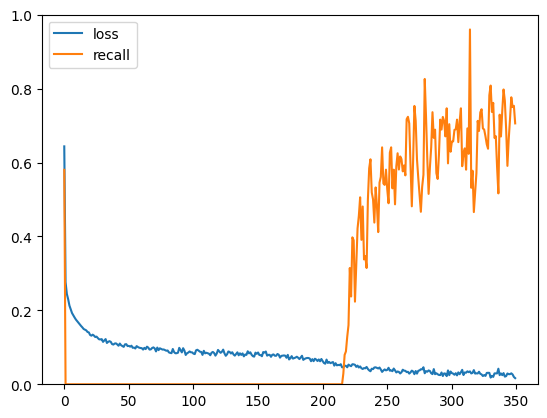

In [6]:
# Plot training metrics

plt.figure()
plt.plot(history['loss'], label="loss")
plt.plot(history['recall'], label="recall")
plt.legend()
plt.ylim(0,1)

In [7]:
### ONNX模型导出

In [8]:
# Export model to ONNX format

output_path = "beary.onnx"
torch.onnx.export(fcn, args=torch.zeros((1, 28, 96)), f=output_path) # the 'args' is the shape of a single example